# Multiaxial Plastic Analysis

In [1]:
if True:
    from veux.canvas.config.beamer import TextWidth, legend_above as legend, format_ticks
    Aspect = 0.6
    WidthSplit = 0.6
    RightStretch = 0.08/(WidthSplit*TextWidth)
    SpaceAbove = 0.2
    SpaceBelow = 0.5
else:
    from veux.canvas.config.beamer import TextWidth, legend_above as legend
    Aspect = 0.6
    WidthSplit = 0.6
    RightStretch = 0.35
    SpaceAbove = 0.08
    SpaceBelow = 0.42

from xsection.library import from_aisc, aisc_data
import matplotlib.pyplot as plt
import numpy as np



def subplots(*args, aspect=Aspect, width=TextWidth*WidthSplit, **kwargs):
    kwargs.pop("figsize", None)
    fig, ax = plt.subplots(*args, **kwargs)
    fig.set_size_inches(width, width * aspect, forward=True)
    return fig, ax

def reserve_margins(
    fig,
    left=0.55,
    right=RightStretch*(WidthSplit*TextWidth),
    bottom=SpaceBelow,
    top=SpaceAbove,
):
    w, h = fig.get_size_inches()

    fig.subplots_adjust(
        left=left / w,
        right=1.0 - right / w,
        bottom=bottom / h,
        top=1.0 - top / h,
    )

## Geometry and Material

In [2]:
from math import sqrt
from xara.units.iks import inch, foot, ksi, kip

In [3]:
import xara 

E = 29e3*ksi
v = 0.3
# Shear modulus
G = E/(2.0*(1.0+v))
# Yield stress
Fy = 60.0*ksi

# Define materials
material = xara.MultiaxialMaterial(
        # "J2BeamThread", 
        "PlasticJ2", #
        E=E, 
        nu=v, 
        Fy=Fy,
        Hiso=0.0001*E, 
        Hkin=0.000*E,
        # Fs=sig0,
        # tol=1e-10,
)

Under multiaxial plasticity, the limit stress in pure shear is given by 
$$
F_{\mathrm{sh}} = \frac{1}{\sqrt3} F_y
$$

In [4]:

Fsh = sqrt(1/3) * Fy

In [5]:
# Create the shape
# shape_name = "W8X40"
# shape_name = "W14x132"
shape_name = "W18x130"

shape = from_aisc(shape_name,
                  material=material, 
                  mesh_type="T3",
                  mesher="gmsh",
                  fillet=False,
                  mesh_scale=1 #0.8
                  )

In [6]:
data = aisc_data(shape_name)

Z = data["Zx"] * inch**3
My = Fy*data["Sx"] * inch**3
A = data["A"] * inch**2
J = data["J"] * inch**4
Io = (data["Ix"] + data["Iy"])* inch**4

Aweb = shape.d * shape.tw

Vyz = Fsh * Aweb
Vyy = Fsh * (A - Aweb)
Tn = 0.6 * Fy * J

print(f"{Vyz = }")
print(f"{A/Aweb = }")
print(f"{Io/J = }")
data

Vyz = 447.94297985346304
A/Aweb = 2.9618745649988396
Io/J = 188.82758620689654


{'A': 38.3,
 'Ix': 2460.0,
 'Iy': 278.0,
 'J': 14.5,
 'Cw': 22700.0,
 'Zx': 290.0,
 'Zy': 76.7,
 'Sx': 256.0,
 'Sy': 49.9,
 'rx': 8.03,
 'ry': 2.7,
 'd': 19.3,
 'bf': 11.2,
 'tw': 0.67,
 'tf': 1.2,
 'kdes': 1.6}

In [7]:
Cv1 = 1.0
Vn = 0.6 * Fy * Aweb * Cv1

In [8]:
from xsection.properties import plastic_torque

def _plastic_torque(shape, Fy):
    Tp = 0.25*shape.tf*shape.bf**2*Fy
    Ts = plastic_torque(shape)*Fy/np.sqrt(3)
    To = Ts #+ Tp*shape.d/test.b[0]
    print(f"{Ts = }, {Tp = }, {To = }")
    return To

print(Tn, _plastic_torque(shape, Fy))
Tn = _plastic_torque(shape, Fy)

Ts = np.float64(678.5501168779526), Tp = 2257.9199999999996, To = np.float64(678.5501168779526)
522.0 678.5501168779526
Ts = np.float64(678.5501168779526), Tp = 2257.9199999999996, To = np.float64(678.5501168779526)


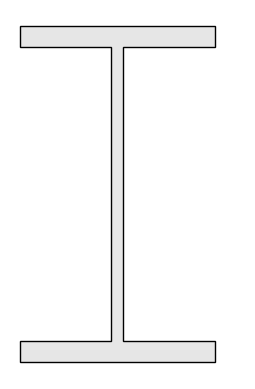

In [9]:
import veux
veux.draw_shape(shape)

In [10]:
Sections = {
    "MultiaxialFiber": xara.Section("MultiaxialFiber", shape, mixed_type="UE"),
    "NDFiber":         xara.Section("NDFiber", shape, mixed_type="UE"),
    "UG": xara.Section("MultiaxialFiber", shape, mixed_type="UG"),
    # "MultiaxialWagner": xara.Section("MultiaxialFiber", shape, mixed_type="UE", wagner=True),
}

## Interaction Analysis


100%|██████████| 43/43 [00:06<00:00,  6.44it/s]


n_failed = 0 (0.0%)
n_missing = 0 (0.0%)


100%|██████████| 43/43 [00:04<00:00,  9.99it/s]


n_failed = 0 (0.0%)
n_missing = 0 (0.0%)


100%|██████████| 43/43 [00:06<00:00,  6.67it/s]


n_failed = 0 (0.0%)
n_missing = 0 (0.0%)


findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern


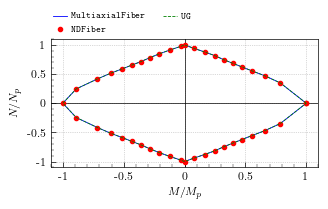

In [11]:
from xsection.analysis import PlasticContour, PlasticLimit

#
# Setup the interaction analysis
#

colors = iter(["blue", "red", "green"])
lines = iter(["-", ".", "--"])
# fig, ax = plt.subplots(constrained_layout=True, figsize=(6, 5))
fig, ax = subplots()
ax.axvline(0, color="black", ls="-", lw=0.5)
ax.axhline(0, color="black", ls="-", lw=0.5)


# Run the analysis for each section
for label, section in Sections.items():
    color = next(colors)
    si = PlasticContour(section,
                        Fj=A*Fy, dof_j="N",
                        Fi=Z*Fy, dof_i="My",
                        overstress=1.1,
                        limit_tol=0.9,
                        limit_state="plastic",
                        limit_stress=Fy,
                        sweep_steps=40
    )
    ax.plot(*np.array(list(si.run())).T, next(lines), label=fr"\ClassName{{{label}}}", color=color)

# ax.axis("equal")
ax.grid(True)
# ax.legend()
ax.set_ylabel("$N/N_p$")
ax.set_xlabel("$M/M_p$");

legend(ax)
format_ticks(ax)
reserve_margins(ax.figure)
ax.figure.savefig("img/nm.pgf",  backend="pgf")

The moment-axial force interaction is identical between `MultiaxialFiber` and `NDFiber` section.


### Moment-Shear 

100%|██████████| 53/53 [00:05<00:00,  9.39it/s]


n_failed = 0 (0.0%)
n_missing = 0 (0.0%)


100%|██████████| 53/53 [00:03<00:00, 13.81it/s]


n_failed = 0 (0.0%)
n_missing = 0 (0.0%)


100%|██████████| 53/53 [00:05<00:00,  9.77it/s]

n_failed = 0 (0.0%)
n_missing = 0 (0.0%)


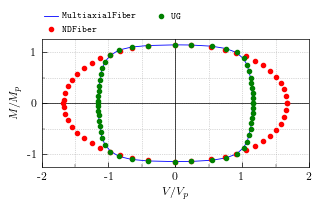

In [12]:

#
# Setup the interaction analysis
#


# fig, ax = plt.subplots(constrained_layout=True, figsize=(8, 5))
fig, ax = subplots()
# ax.axvline(Fsh*A/Vy, color="black", ls="--", lw=0.5)
ax.axvline(0, color="black", ls="-", lw=0.5)
ax.axhline(0, color="black", ls="-", lw=0.5)


colors = iter(["blue", "red", "green"])
lines = iter(["-", ".", "."])
for label, section in Sections.items():
    color = next(colors)
    si = PlasticContour(section, 
                        Fi=Vyz, dof_i="Vz",
                        Fj=My, dof_j="My",
                        overstress=shape.area/Aweb,
                        limit_tol=0.99,
                        limit_state="plastic",
                        limit_stress=Fy)
    ax.plot(*np.array(list(si.run())).T, next(lines),
            label=fr"\ClassName{{{label}}}", color=color)
    # si = PlasticContour(section, 
    #                     Fi=Vy, dof_i="Vz",
    #                     Fj=My, dof_j="My",
    #                     overstress=shape.area/Aweb,
    #                     steps=400,
    #                     limit_state="elastic",
    #                     limit_stress=Fy)
    # ax.plot(*np.array(list(si.run())).T, "--",  color=color)


ax.grid(True)
ax.set_xlabel("$V/V_{p}$")
ax.set_ylabel("$M/M_{p}$");

# ax.legend()
legend(ax)
format_ticks(ax,
             yticks=[-1,0,1], #[-1.5, -1, -0.5, 0, 0.5, 1, 1.5],
            #  xticks=[-1.5, -1, -0.5, 0, 0.5, 1, 1.5]
            xticks=[-2,-1,0,1,2],
            minor=True
            )
reserve_margins(ax.figure)
ax.figure.savefig("img/mv.pgf",  backend="pgf")

  6%|▌         | 3/53 [00:00<00:16,  3.09it/s]

  Failed to converge in section, residual = 4.04873e+06
LoadControl::update - model failed to update for new dU
   FAILURE :: Failed to update the model
  Failed to converge in section, residual = 4.04894e+06
  Failed to converge in section, residual = 3.74329e+06
LoadControl::update - model failed to update for new dU
   FAILURE :: Failed to update the model
  Failed to converge in section, residual = 4.04894e+06
  Failed to converge in section, residual = 225.814
LoadControl::update - model failed to update for new dU
   FAILURE :: Failed to update the model
  Failed to converge in section, residual = 4.04894e+06
  Failed to converge in section, residual = 4.03357e+08
LoadControl::update - model failed to update for new dU
   FAILURE :: Failed to update the model
  Failed to converge in section, residual = 4.04894e+06
  Failed to converge in section, residual = 8818.8
LoadControl::update - model failed to update for new dU
   FAILURE :: Failed to update the model
  Failed to converge

  8%|▊         | 4/53 [00:01<00:16,  2.96it/s]

  Failed to converge in section, residual = 2.94145e+06
LoadControl::update - model failed to update for new dU
   FAILURE :: Failed to update the model
  Failed to converge in section, residual = 4.0179e+06
  Failed to converge in section, residual = 4.01652e+06
LoadControl::update - model failed to update for new dU
   FAILURE :: Failed to update the model
  Failed to converge in section, residual = 4.0179e+06
  Failed to converge in section, residual = 125434
LoadControl::update - model failed to update for new dU
   FAILURE :: Failed to update the model
  Failed to converge in section, residual = 4.0179e+06
  Failed to converge in section, residual = 55855.6
LoadControl::update - model failed to update for new dU
   FAILURE :: Failed to update the model
  Failed to converge in section, residual = 4.0179e+06
  Failed to converge in section, residual = 2340.03
LoadControl::update - model failed to update for new dU
   FAILURE :: Failed to update the model
  Failed to converge in sect

  9%|▉         | 5/53 [00:01<00:16,  2.91it/s]

...

n_failed = 22 (44.0%)
n_missing = 0 (0.0%)


100%|██████████| 53/53 [00:09<00:00,  5.68it/s]


n_failed = 0 (0.0%)
n_missing = 0 (0.0%)


100%|██████████| 53/53 [00:16<00:00,  3.24it/s]

n_failed = 0 (0.0%)
n_missing = 0 (0.0%)


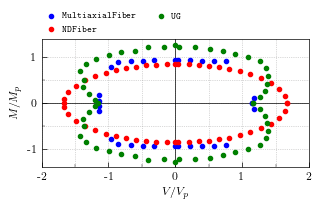

In [17]:

#
# Setup the interaction analysis
#


# fig, ax = plt.subplots(constrained_layout=True, figsize=(8, 5))
fig, ax = subplots()
# ax.axvline(Fsh*A/Vy, color="black", ls="--", lw=0.5)
ax.axvline(0, color="black", ls="-", lw=0.5)
ax.axhline(0, color="black", ls="-", lw=0.5)


colors = iter(["blue", "red", "green"])
lines = iter([".", ".", "."])
for label, section in Sections.items():
    # continue
    color = next(colors)

    si = PlasticContour(section, 
                        Fi=Vyz, dof_i="Vz",
                        Fj=Vyy, dof_j="Vy",
                        overstress=shape.area/Aweb,
                        limit_tol=0.98,
                        steps=1200,
                        limit_state="plastic",
                        limit_stress=Fy)

    ax.plot(*np.array(list(si.run())).T, next(lines),
            label=fr"\ClassName{{{label}}}", color=color)



ax.grid(True)
ax.set_xlabel("$V/V_{p}$")
ax.set_ylabel("$M/M_{p}$");

# ax.legend()
legend(ax)
format_ticks(ax,
             yticks=[-1,0,1], #[-1.5, -1, -0.5, 0, 0.5, 1, 1.5],
            #  xticks=[-1.5, -1, -0.5, 0, 0.5, 1, 1.5]
            xticks=[-2,-1,0,1,2],
            minor=True
            )
reserve_margins(ax.figure)
ax.figure.savefig("img/vv.pgf",  backend="pgf")

- When `NDFiber` is loaded in pure shear, all fibers go plastic at the same time. `MultiaxialFiber` exhibits a gradual transition to the plastic shear
- In the state of ultimate plastic shear, `NDFiber` produces a uniform stress field $\boldsymbol{\sigma} = (0, 0, F_{\mathrm{sh}})$, but the resultant is not $\int F_{\mathrm{sh}}\, dA$

### Torsion-Shear

Running MultiaxialFiber...


100%|██████████| 63/63 [00:27<00:00,  2.31it/s]


n_failed = 0 (0.0%)
n_missing = 4 (6.7%)
Running NDFiber...


100%|██████████| 53/53 [00:11<00:00,  4.74it/s]


n_failed = 0 (0.0%)
n_missing = 16 (32.0%)
Running UG...


100%|██████████| 53/53 [00:09<00:00,  5.53it/s]


n_failed = 0 (0.0%)
n_missing = 20 (40.0%)


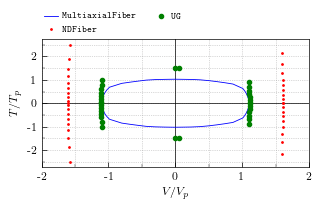

In [14]:
colors = iter(["blue", "red", "green"])
lines = iter(["-", ".", "."])

# fig, ax = plt.subplots(constrained_layout=True, figsize=(6, 5))
fig, ax = subplots()
ax.axvline(0, color="black", ls="-", lw=0.5)
ax.axhline(0, color="black", ls="-", lw=0.5)

# ax.axvline(Vn, color="black", ls="--", lw=0.5)
# ax.axvline(Vy, color="black", ls="--", lw=0.5)

# Run the analysis for each section
Parameters = {
    "NDFiber": {"overstress": 3, "steps": 800, "sweep_steps": 50},
    "MultiaxialFiber": {"overstress": 1.2, "steps": 800, "sweep_steps": 60},
    "MultiaxialWagner": {"overstress": 5.0, "steps": 800, "sweep_steps": 60},
}
Styles = {
    "NDFiber": {"ms": 2},
    "MultiaxialFiber": {},
    "MultiaxialWagner": {"ms": 2}
}

for label, section in Sections.items():
    print(f"Running {label}...")
    color = next(colors)
    si = PlasticContour(section,
                        Fi=Vn, dof_i="Vz",
                        Fj=Tn, dof_j="T",
                        # overstress=1.1,
                        # overstress=5, #shape.area/Aweb,
                        # steps=800,
                        # sweep_steps=50,
                        **Parameters.get(label, {}),
                        limit_tol=0.95,
                        limit_state="plastic",
                        limit_stress=Fy,
                        normalize=True
    )
    ax.plot(*np.array(list(si.run())).T, next(lines), 
            label=fr"\ClassName{{{label}}}", 
            color=color, **Styles.get(label, {}))

    # si = PlasticContour(section,
    #                     Fi=Vn, dof_i="Vz",
    #                     Fj=Tn, dof_j="T",
    #                     # overstress=1.1,
    #                     overstress=shape.area/Aweb,
    #                     steps=400,
    #                     limit_state="elastic",
    #                     limit_stress=Fy,
    #                     sweep_steps=60,
    #                     normalize=True
    # )
    # ax.plot(*np.array(list(si.run())).T, ":", label=label, color=color)

# ax.axis("equal")
ax.grid(True)
# ax.legend()
ax.set_xlabel("$V/V_{p}$")
ax.set_ylabel("$T/T_{p}$");

legend(ax)
format_ticks(ax,
             yticks=[-2,-1,0,1,2],
             xticks=[-2,-1,0,1,2],
             minor=True
             )
reserve_margins(ax.figure)
ax.figure.savefig("img/vt.pgf",  backend="pgf")

### Axial-Torsion

Running MultiaxialFiber...


100%|██████████| 63/63 [00:27<00:00,  2.28it/s]


n_failed = 0 (0.0%)
n_missing = 0 (0.0%)
Running NDFiber...


100%|██████████| 53/53 [00:12<00:00,  4.20it/s]


n_failed = 0 (0.0%)
n_missing = 24 (48.0%)
Running UG...


100%|██████████| 53/53 [00:09<00:00,  5.56it/s]


n_failed = 5 (10.0%)
n_missing = 0 (0.0%)


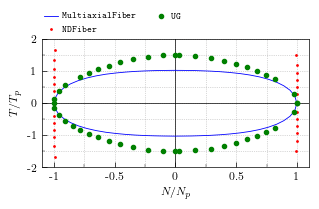

In [15]:
colors = iter(["blue", "red", "green"])
lines = iter(["-", ".", "."])

# fig, ax = plt.subplots(constrained_layout=True, figsize=(6, 5))
fig, ax = subplots()
ax.axvline(0, color="black", ls="-", lw=0.5)
ax.axhline(0, color="black", ls="-", lw=0.5)

# ax.axvline(Vn, color="black", ls="--", lw=0.5)
# ax.axvline(Vy, color="black", ls="--", lw=0.5)

# Run the analysis for each section
Parameters = {
    "NDFiber": {"overstress": 2, "steps": 800, "sweep_steps": 50},
    "MultiaxialFiber": {"overstress": 1.1, "steps": 800, "sweep_steps": 60},
    "MultiaxialWagner": {"overstress": 4.0, "steps": 800, "sweep_steps": 200},
}
Styles = {
    "NDFiber": {"ms": 2},
    "MultiaxialFiber": {},
    "MultiaxialWagner": {"ms": 2}
}

for label, section in Sections.items():
    print(f"Running {label}...")
    color = next(colors)
    si = PlasticContour(section,
                        Fi=A*Fy, dof_i="N",
                        Fj=Tn,   dof_j="T",
                        # overstress=1.1,
                        # overstress=5, #shape.area/Aweb,
                        # steps=800,
                        # sweep_steps=50,
                        **Parameters.get(label, {}),
                        limit_tol=0.995,
                        limit_state="plastic",
                        limit_stress=Fy,
                        normalize=True
    )
    ax.plot(*np.array(list(si.run())).T, 
            next(lines), 
            label=fr"\ClassName{{{label}}}", 
            color=color, **Styles.get(label, {}))
    # si = PlasticContour(section,
    #                     Fi=Vn, dof_i="Vz",
    #                     Fj=Tn, dof_j="T",
    #                     # overstress=1.1,
    #                     overstress=shape.area/Aweb,
    #                     steps=400,
    #                     limit_state="elastic",
    #                     limit_stress=Fy,
    #                     sweep_steps=60,
    #                     normalize=True
    # )
    # ax.plot(*np.array(list(si.run())).T, ":", label=label, color=color)

# ax.axis("equal")
ax.grid(True)
# ax.legend()
ax.set_xlabel("$N/N_{p}$")
ax.set_ylabel("$T/T_{p}$");

legend(ax)
format_ticks(ax,
             yticks=[-2,-1,0,1,2],
             xticks=[-1,-0.5,0,0.5,1],
             minor=True
             )
reserve_margins(ax.figure)
ax.figure.savefig("img/nt.pgf",  backend="pgf")

## Limits

In [16]:
raise Exception("Stop here")

from xara.post import FiberStress
fig, ax = plt.subplots(1,2, constrained_layout=True, figsize=(10, 5))

i = 0
for label, section in Sections.items():
    pl = PlasticLimit(section, [A*Fy,0,0,  0, 0, 0], Fy, overstress=1.1)

    Np = 0
    for j, f in _get_fibers(pl.model, 1).items():
        Np += pl.model.eleResponse(1, "section", "fiber", j, "stress")[0]*f["area"]
    print(Np/(A*Fy))
    print(pl.resultant[0]/(A*Fy))

    ax[i].set_title(label + f", $N_p = {-pl.reaction[0]:.2f}$")


    artist = veux.ShapeArtist(shape, 
                              ax=ax[i])

    stress_field = FiberStress(pl.model, shape, section=1, stress="svm", element=1)
    artist.draw_surfaces(
        field=stress_field,
        cbar_label="Von Mises Stress (ksi)",
    )
    i += 1

Exception: Stop here

### Moment

In [ ]:
from xara.post import FiberStress, NodalAverage
from xsection.analysis.interaction.shear import _get_fibers
fig, ax = plt.subplots(1,2, constrained_layout=True, figsize=(10, 5))

i = 0
for label, section in Sections.items():
    pl = PlasticLimit(section, [0,0,0,  0, Z*Fy, 0], Fy, overstress=1.1)

    Mp = 0
    for j, f in _get_fibers(pl.model, 1).items():
        z = f.get("coord", f.get("location",[None,f.get("z",None)]))[1]
        Mp += pl.model.eleResponse(1, "section", "fiber", j, "stress")[0]*f["area"]*z
    print(Mp/(Z*Fy))
    print(pl.reaction[4]/(Z*Fy))

    ax[i].set_title(label + f", $M_p = {-pl.reaction[4]:.2f}$")

    if i > 1:
        continue


    artist = veux.ShapeArtist(shape, 
                              ax=ax[i])

    stress_field = FiberStress(pl.model, shape, section=1, stress="svm", element=1, scale=1/Fy)
    artist.draw_surfaces(
        field=stress_field,
        cbar_label="Von Mises Stress (ksi)",
    )
    i += 1

### Shear

In [ ]:

fig, ax = plt.subplots(1,2, constrained_layout=True, figsize=(10, 5))

print("Vn = ", Vn)
print("Vp = ", Fsh*A)
# section = xara.Section("NDFiber", shape, mixed_type="UE")
i = 0
for label, section in Sections.items():
    pl = PlasticLimit(section, [0, 0, Vyz, 0, 0, 0], Fy, overstress=A/Aweb)

    Vp = 0
    for j, f in _get_fibers(pl.model, 1).items():
        Vp += pl.model.eleResponse(1, "section", "fiber", j, "stress")[2]*f["area"]
    print("V = ", Vp)
    print("R = ", -pl.reaction[2])


    if i > 1:
        continue

    ax[i].set_title(label + f", $V_p = {-pl.reaction[2]:.2f}$")


    artist = veux.ShapeArtist(shape, 
                              ax=ax[i])

    stress_field = FiberStress(pl.model, shape, section=1, stress="svm", element=1, scale=1/Fy)
    artist.draw_surfaces(
        field=stress_field,
        cbar_label="Von Mises Stress (ksi)",
    )
    i += 1

In [ ]:

fig, ax = plt.subplots(1,2, constrained_layout=True, figsize=(10, 5))

a = np.pi/10
i = 0
for label, section in Sections.items():
    pl = PlasticLimit(section, [A*Fy*np.sin(a),0,0,  
                                0, Z*Fy*np.cos(a), 0], 
                                Fy, overstress=1.1)

    Mp = 0
    for j, f in _get_fibers(pl.model, 1).items():
        z = f.get("coord", f.get("location",[None,f.get("z",None)]))[1]
        Mp += pl.model.eleResponse(1, "section", "fiber", j, "stress")[0]*f["area"]*z
    print(Mp/(Z*Fy))
    print(pl.reaction[4]/(Z*Fy))
    if i > 1:
        continue

    ax[i].set_title(label + f", $M_p = {-pl.reaction[4]:.2f}$")


    artist = veux.ShapeArtist(shape, 
                              ax=ax[i])

    stress_field = FiberStress(pl.model, shape, section=1, stress="svm", element=1)
    artist.draw_surfaces(
        field=stress_field,
        cbar_label="Von Mises Stress (ksi)",
    )
    i += 1